<div align="center">
    
<h2>PROJECT MODULE</h2>
<h4>Beyond Accuracy: Evaluating the stability of SHAP explanations Across Machine Learning Models for PISA 2022 Mathematics in Switzerland</h4>

</div>

<br>

**Author:** Lucas Pannatier  
**Institution:** University of London (Birkbeck College), Msc in Computer Science  
**Date:** 2026


<br>
<br>



##### **I. BUILD AND LOAD THE DATASET**

For this project, a Swiss PISA 2022 dataset reduced to the 20 features discussed in the project report has been built from the official PISA 2022 database (https://survey.oecd.org/index.php?r=survey/index&sid=197663&lang=en):

- the dataset resulting from the school questionnaire: CY08MSP_SCH_QQQ.sav (18.53 MB) 
- the dataset based on the student questionnaire: CY08MSP_STU_QQQ.sav (1.97 GB)

Code has been developed to build the Swiss reduced PISA 2022 dataset from scratch. If the user wants to do it this way, it requires manual download of the official database (a direct link is also available here: https://zenodo.org/records/13382904).

Otherwise, the Swiss reduced PISA 2022 dataset is already available in the dataset folder for the purpose of this study.


In [1]:
import os
import sys
import pandas as pd
from pathlib import Path

if Path.cwd().name == "notebook":
    os.chdir(Path.cwd().parent)

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataset_building import reduced_swiss_dataset

print("Working directory:", os.getcwd())

df_raw = "dataset/swiss_reduced_dataset.csv"

if not os.path.exists(df_raw):
    # Build the reduced Swiss dataset from PISA 2022 dataset
    # Requires manual download of the original PISA files
    df_raw = reduced_swiss_dataset()
else:
    df_raw = pd.read_csv(df_raw)

Working directory: /Users/lucaspannatier/Google Drive/UNIVERSITY OF LONDON/Master in Computer Science/Project/Project and code/PROJECT_CODE


##### **II. PREPROCESSING PROCESS**

This preprocessing pipeline performs the following steps:

1. prepares the raw dataset before splitting by removing variables and rows exceeding the missing value threshold, creating derived features (such as `MMINS` and `MEAN_ESCS`), capping extreme outliers, and mapping ordinal variables to numerical values.

2. splits the dataset into a training (70%) and a test (30%) set.

3. filters variables based on the training data only, imputes missing values, and one-hot encodes nominal variables for both the X_train and X_test datasets.


In [2]:
from src.config import MISSING_VALUES_THRESHOLD
from src.dataset_cleaning_and_preprocessing import run_preprocessing_pipeline


(X_train_imputed, 
 X_test_imputed, 
 X_train, X_test, 
 y_train, y_test, 
 df_raw_with_correct_features, 
 df_preprocessed, 
 numeric_imputed_feature_names, 
 all_imputed_feature_names, 
 removed_missing_columns) = run_preprocessing_pipeline(df_raw, MISSING_VALUES_THRESHOLD)

##### **III. GLOBAL EXPLORATORY DATA ANALYSIS**

This step saves and displays only descriptive statistics about the whole dataset, before cleaning and imputing, in the form of plots and tables. Performing the exploratory data analysis at this stage helps avoid data leakage.



 • Global Data Exploratory Analysis (whole dataset before cleaning).txt saved to outputs/tables/EDA/whole_dataset/Global Data Exploratory Analysis (whole dataset before cleaning).txt

 • Global Data Exploratory Analysis (Cleaned Whole Dataset).txt saved to outputs/tables/EDA/whole_dataset/Global Data Exploratory Analysis (Cleaned Whole Dataset).txt

 • Missing Values Report (before cleaning).txt saved to outputs/tables/EDA/whole_dataset/Missing Values Report (before cleaning).txt

 • 15 histograms saved to outputs/plots/EDA/whole_dataset/univariate_plots/histograms

 • 15 violin plots saved to outputs/plots/EDA/whole_dataset/univariate_plots/violin_plots

 • 5 bar plots saved to outputs/plots/EDA/whole_dataset/univariate_plots/barplots/

 • Histograms - All Numeric Features (Before Cleaning And Imputation).png saved to outputs/plots/EDA/whole_dataset/univariate_plots/histograms/

 • Violin Plots - All Numeric Features (Before Cleaning And Imputation).png saved to outputs/plots/EDA/who

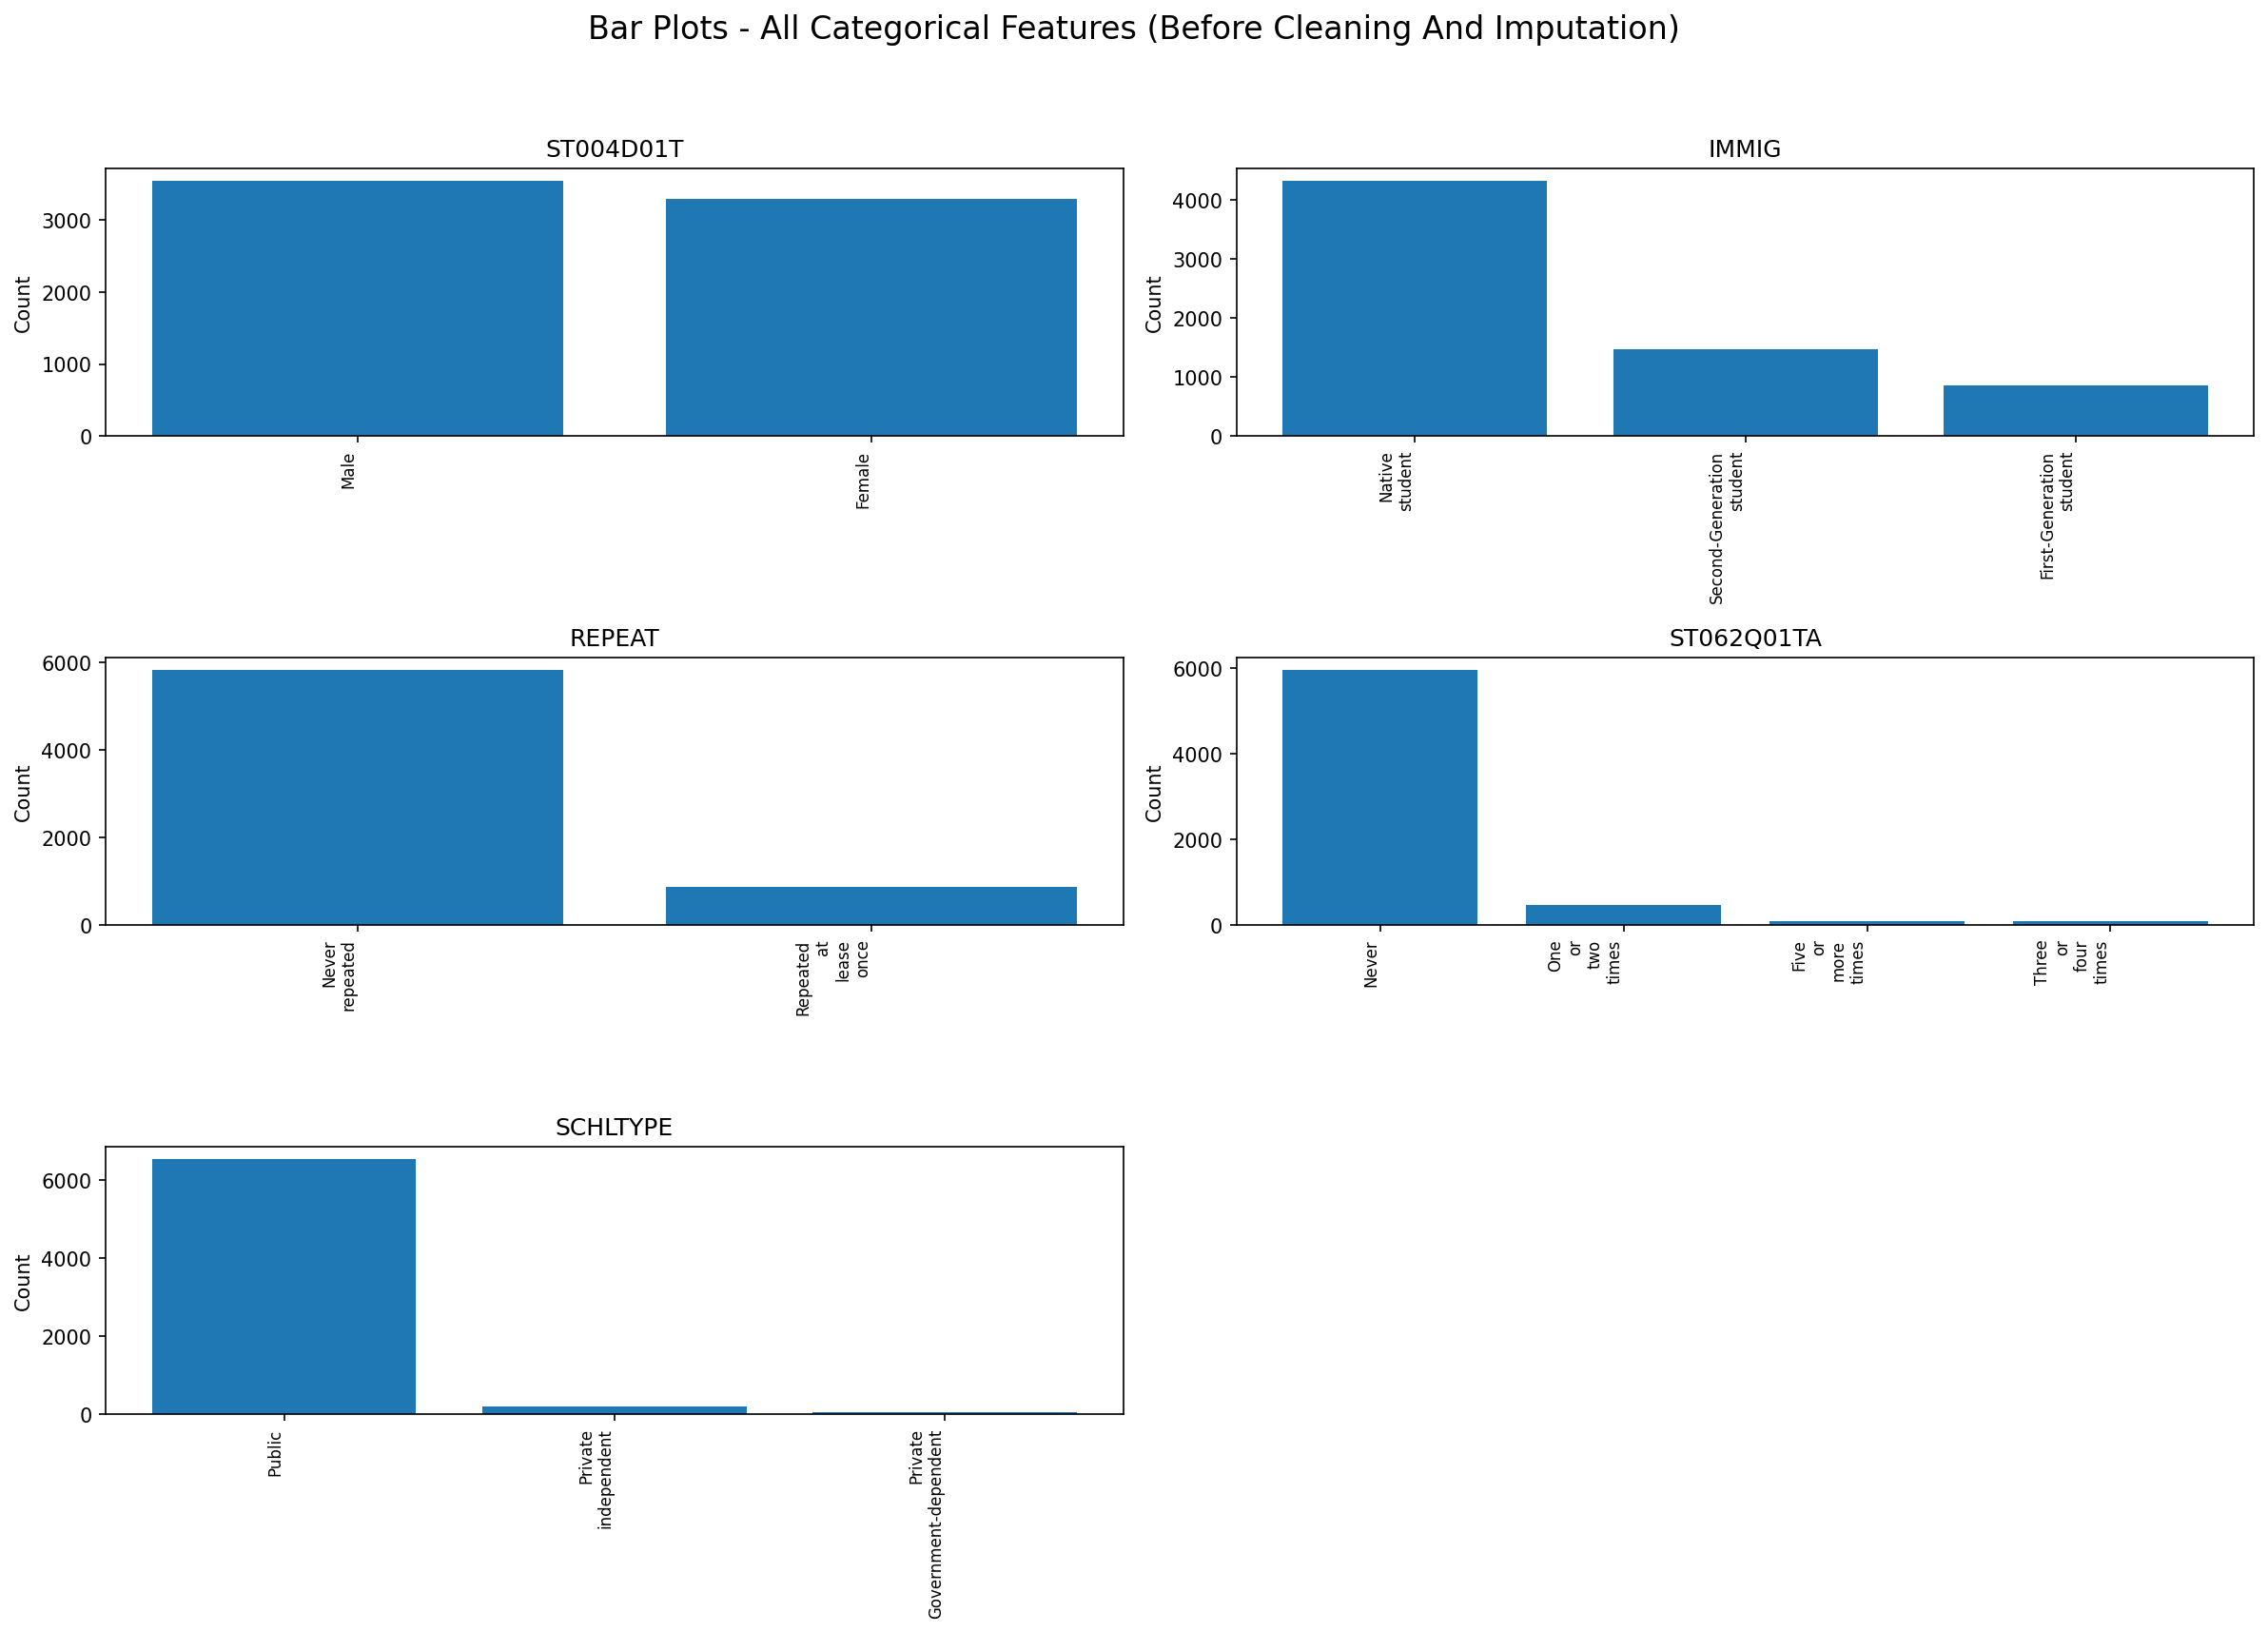

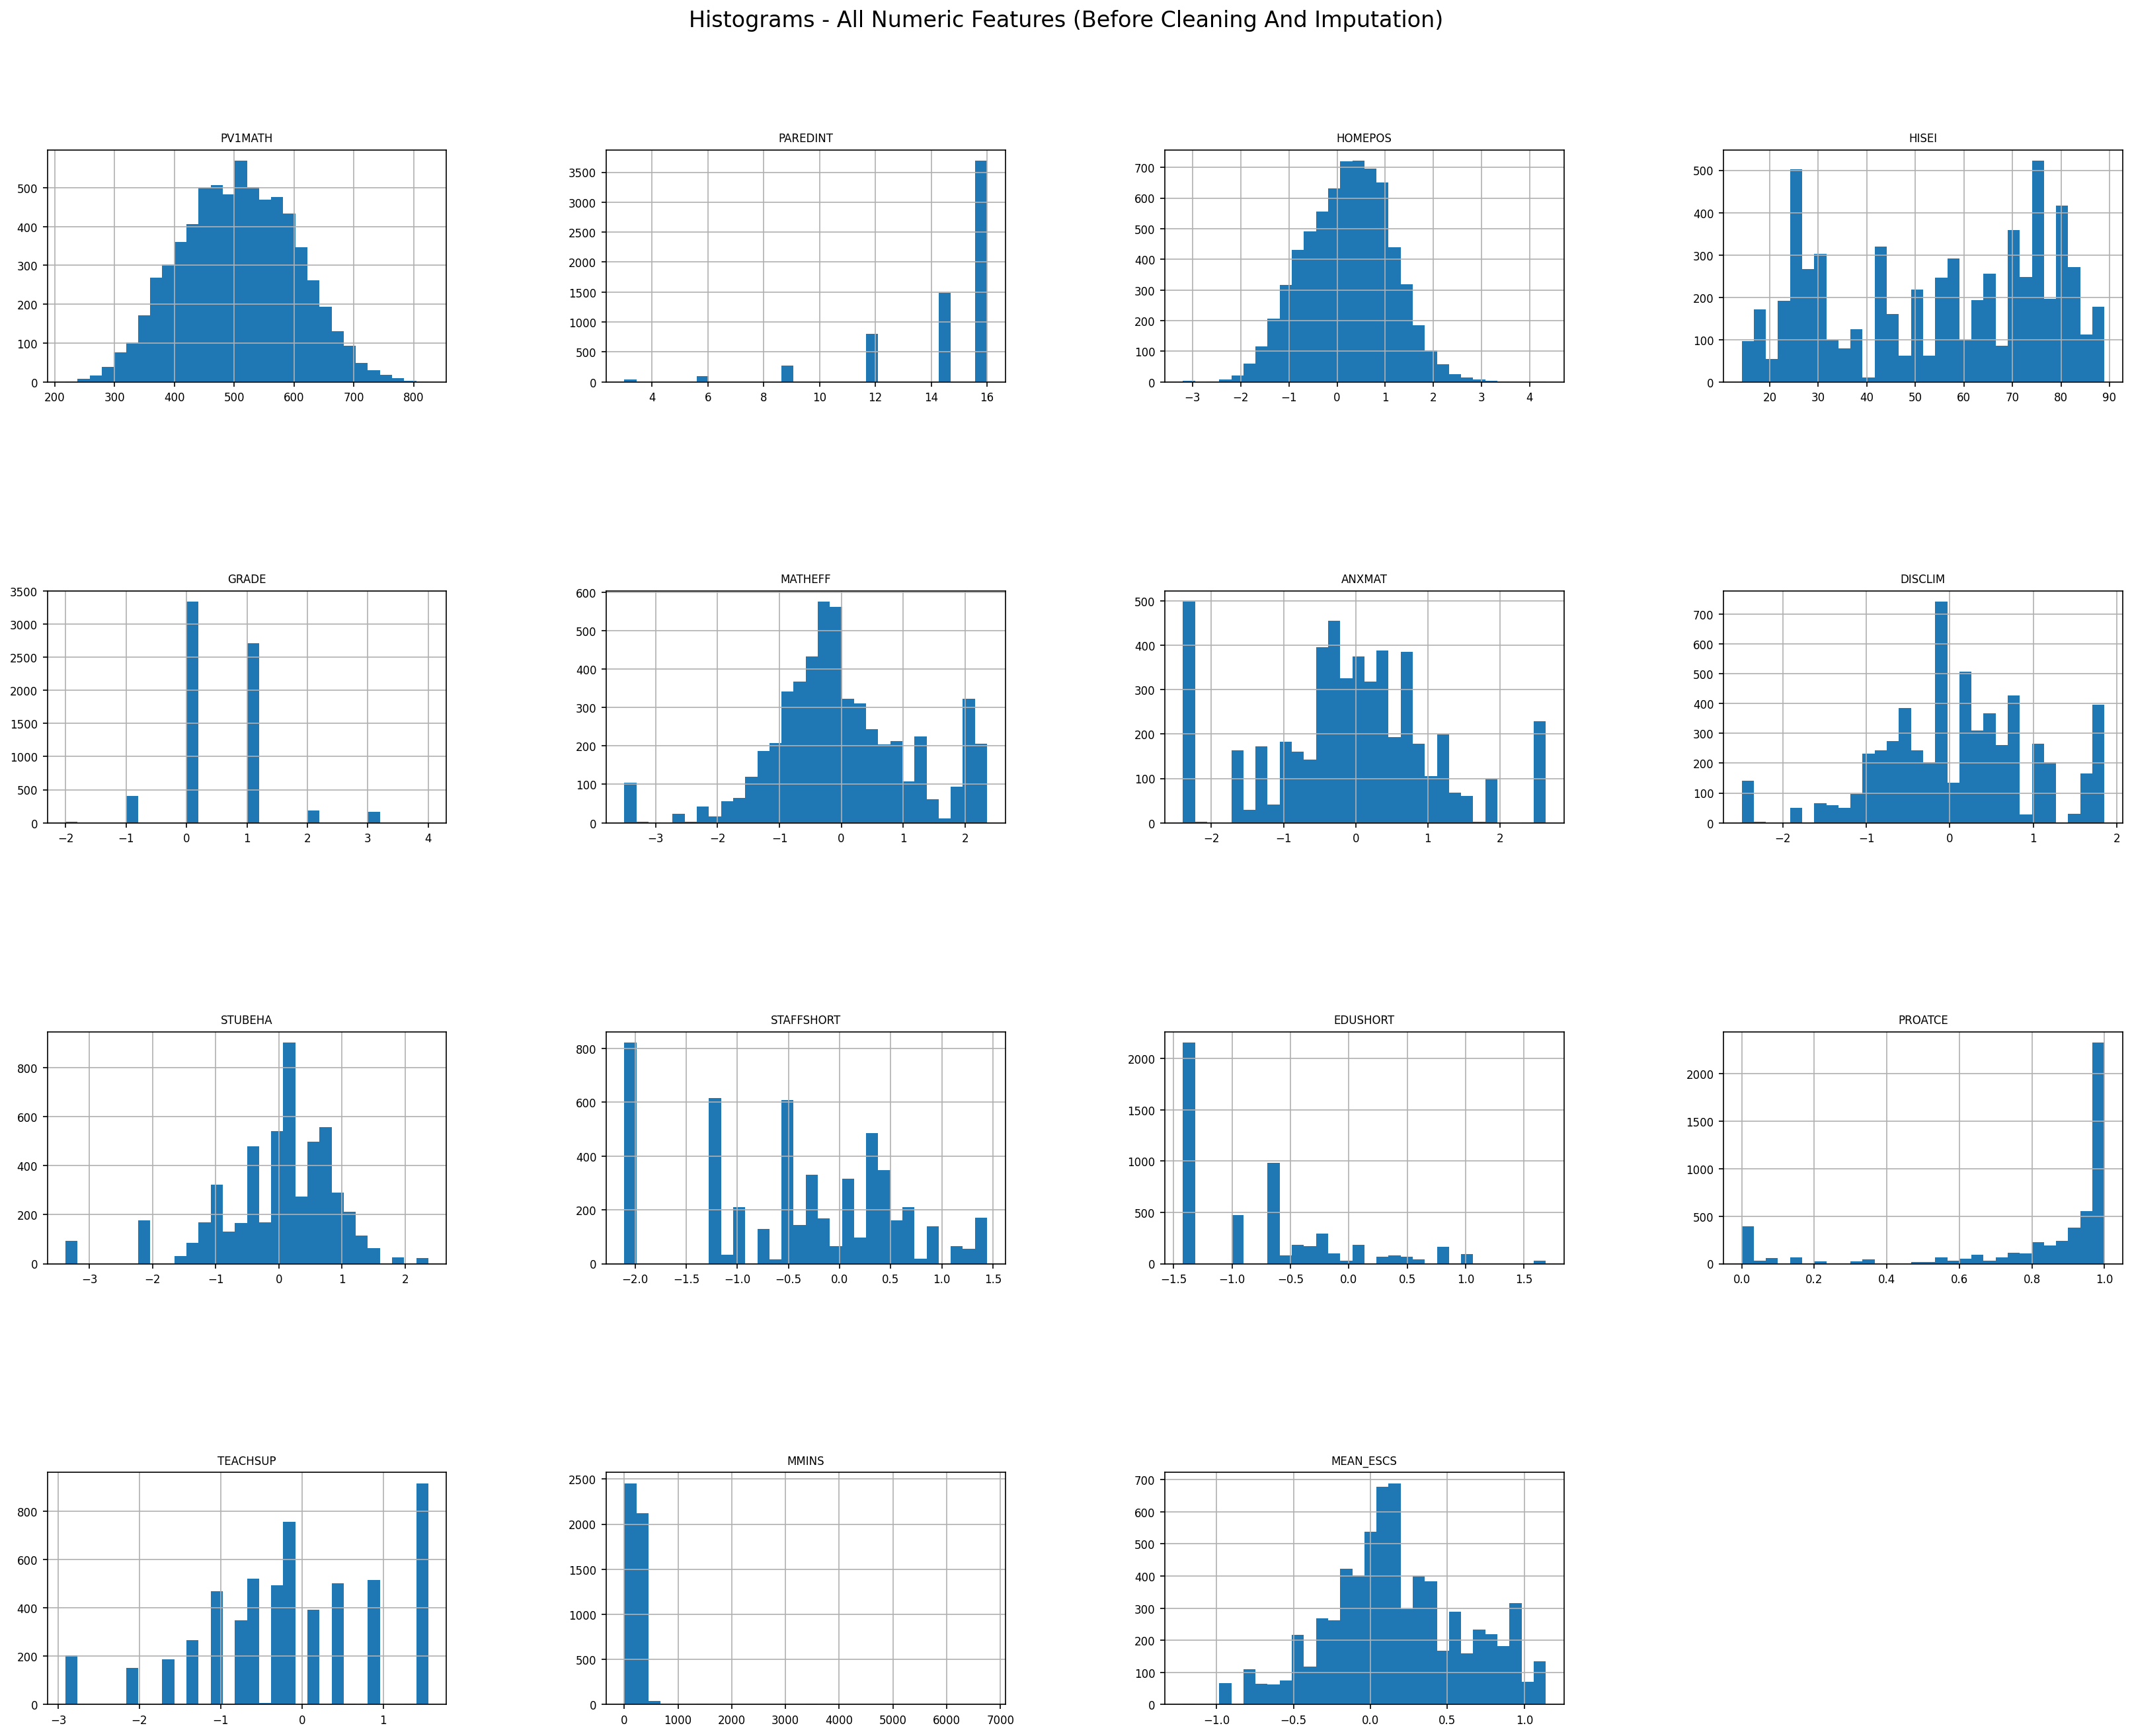

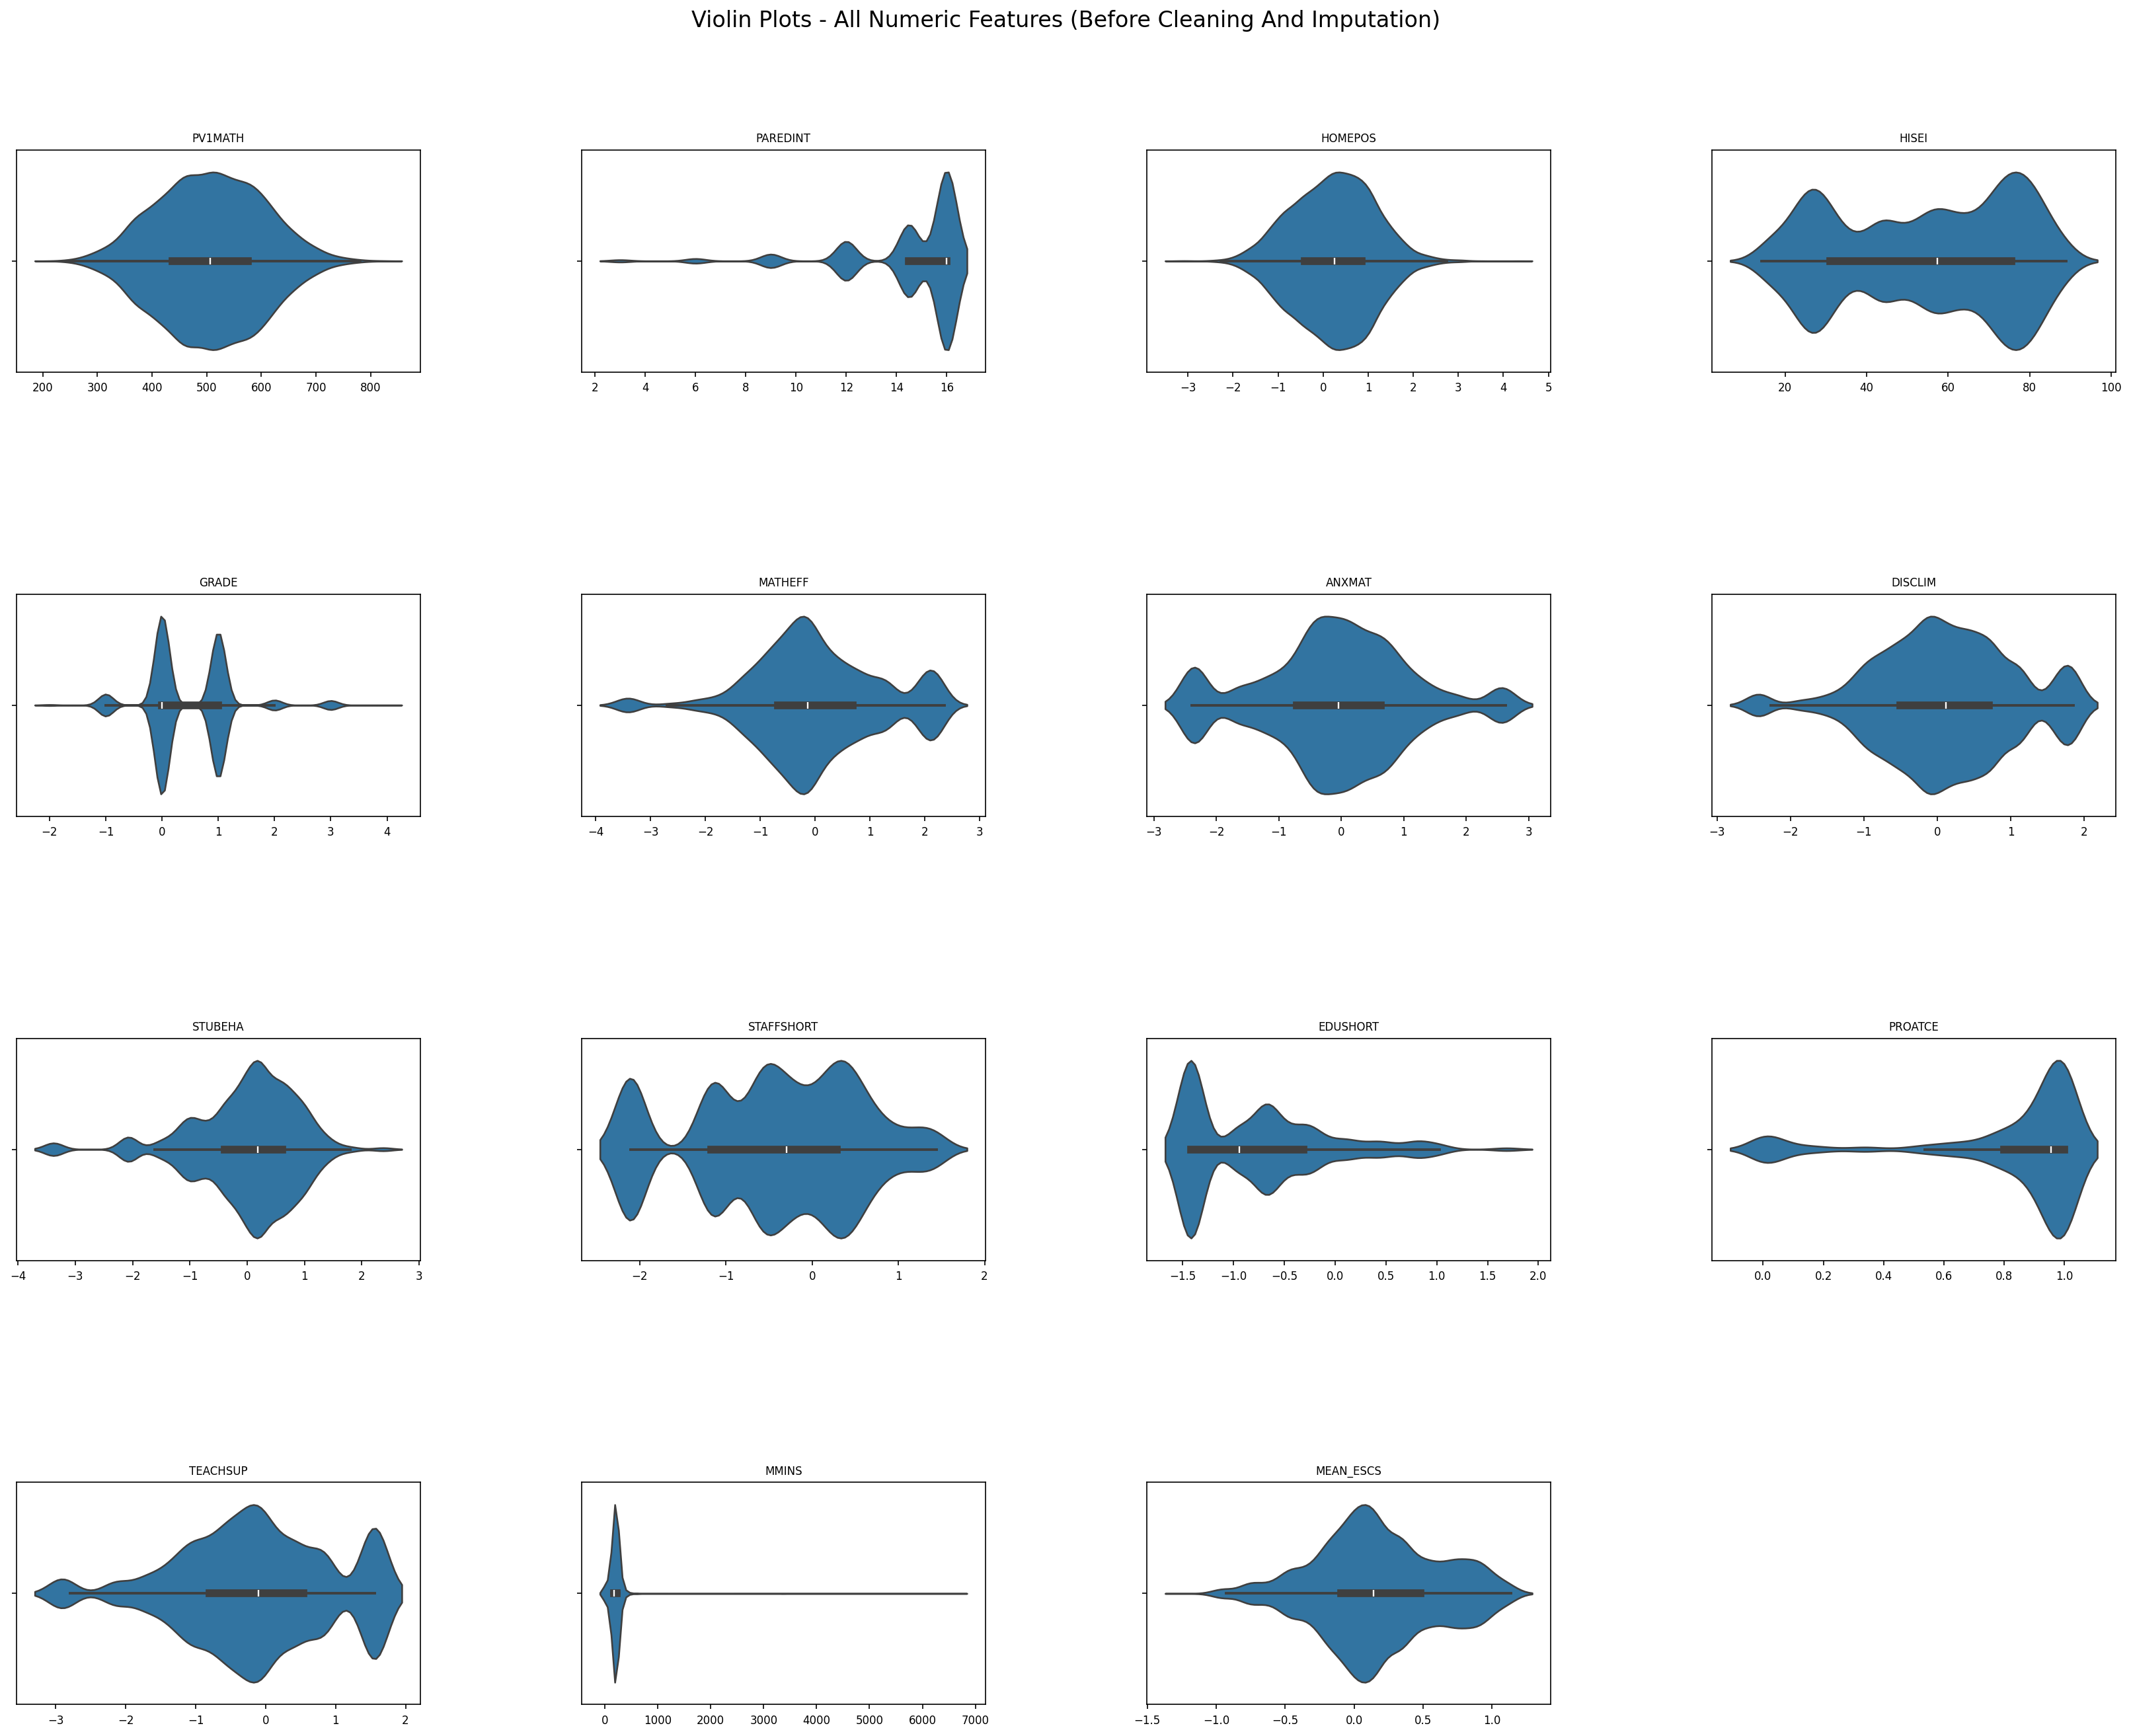


Global Data Exploratory Analysis (Cleaned Whole Dataset)

SHAPE OF THE DATASET

(6812, 20)

HEAD OF THE DATASET

   PV1MATH  PAREDINT  HOMEPOS  HISEI  GRADE ST004D01T  IMMIG  MATHEFF  ANXMAT  \
0  549.176      14.5   0.2982  28.48    0.0      Male    1.0   0.2141 -1.1715   
1  600.101      12.0  -1.0015  30.34    1.0      Male    2.0   0.9211 -0.2758   
2  624.078      14.5   0.9925  43.85    2.0    Female    2.0  -0.3312  0.6647   
3  454.898      16.0   0.1823  70.89    0.0    Female    1.0  -1.5783  0.3729   
4  351.327      12.0  -0.8671  26.80    0.0    Female    3.0      NaN     NaN   

   REPEAT  ST062Q01TA  DISCLIM  STUBEHA  STAFFSHORT  EDUSHORT  PROATCE  \
0     1.0         1.0   0.7652      NaN         NaN       NaN      NaN   
1     0.0         1.0   0.6318   0.2498     -0.5635   -0.9432      NaN   
2     0.0         2.0  -0.6497  -2.0719     -0.9675   -0.9490   0.9065   
3     0.0         1.0   0.1201  -0.5078      1.4261   -0.6483   0.9767   
4     1.0         1.0      Na

In [4]:
from src.config import OUTPUTS_DIR, PLOTS_DIR, TABLES_DIR
from src.tables import save_descriptive_statistics, save_missing_values_report
from src.utils import display_visualisation, print_files
from src.visualisations import save_combined_barplots, save_combined_histograms, save_combined_violin_plots, save_individual_barplots, save_individual_histograms, save_individual_violin_plots

for dir_path in [OUTPUTS_DIR, TABLES_DIR, PLOTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# Data analysis: generate tables
save_descriptive_statistics(df_raw_with_correct_features, "Global Data Exploratory Analysis (whole dataset before cleaning)")
save_descriptive_statistics(df_preprocessed, "Global Data Exploratory Analysis (Cleaned Whole Dataset)")
save_missing_values_report(df_raw_with_correct_features, MISSING_VALUES_THRESHOLD, "Missing Values Report (before cleaning)")

# Data analysis: generate plots 
save_individual_histograms(df_raw_with_correct_features, "Before Cleaning")
save_individual_violin_plots(df_raw_with_correct_features, "Before Cleaning")
save_individual_barplots(df_raw_with_correct_features, "Before Cleaning")
save_combined_histograms(df_raw_with_correct_features)
save_combined_violin_plots(df_raw_with_correct_features)
save_combined_barplots(df_raw_with_correct_features)

# Data analysis: display tables and plots
print_files("outputs/tables/EDA/whole_dataset/Global Data Exploratory Analysis (whole dataset before cleaning).txt")
print_files("outputs/tables/EDA/whole_dataset/Missing Values Report (before cleaning).txt")
display_visualisation("outputs/plots/EDA/whole_dataset/univariate_plots/barplots/Bar Plots - All Categorical Features (Before Cleaning And Imputation).png")
display_visualisation("outputs/plots/EDA/whole_dataset/univariate_plots/histograms/Histograms - All Numeric Features (Before Cleaning And Imputation).png")
display_visualisation("outputs/plots/EDA/whole_dataset/univariate_plots/violin_plots/Violin Plots - All Numeric Features (Before Cleaning And Imputation).png")
print_files("outputs/tables/EDA/whole_dataset/Global Data Exploratory Analysis (Cleaned Whole Dataset).txt")


##### **IV. EXPLORATORY DATA ANALYSIS ON TRAIN-SET AFTER IMPUTATION**

This step performs an exploratory analysis of the training dataset after imputation to identify correlations among the variables (potential multicollinearity) as well as correlations between the variables and the target variable (PV1MATH). 

The goal is to identify the variables that appear to be most strongly associated with the target variable prior to variable selection.


 • Spearman Correlation Matrix (Train set after imputation).png saved to outputs/plots/EDA/train_set/multivariate_plots/

 • correlations_with_PV1MATH.txt saved to outputs/tables/EDA/train_set/correlations_with_PV1MATH.txt

 • correlations_among_features.txt saved to outputs/tables/EDA/train_set/correlations_among_features.txt


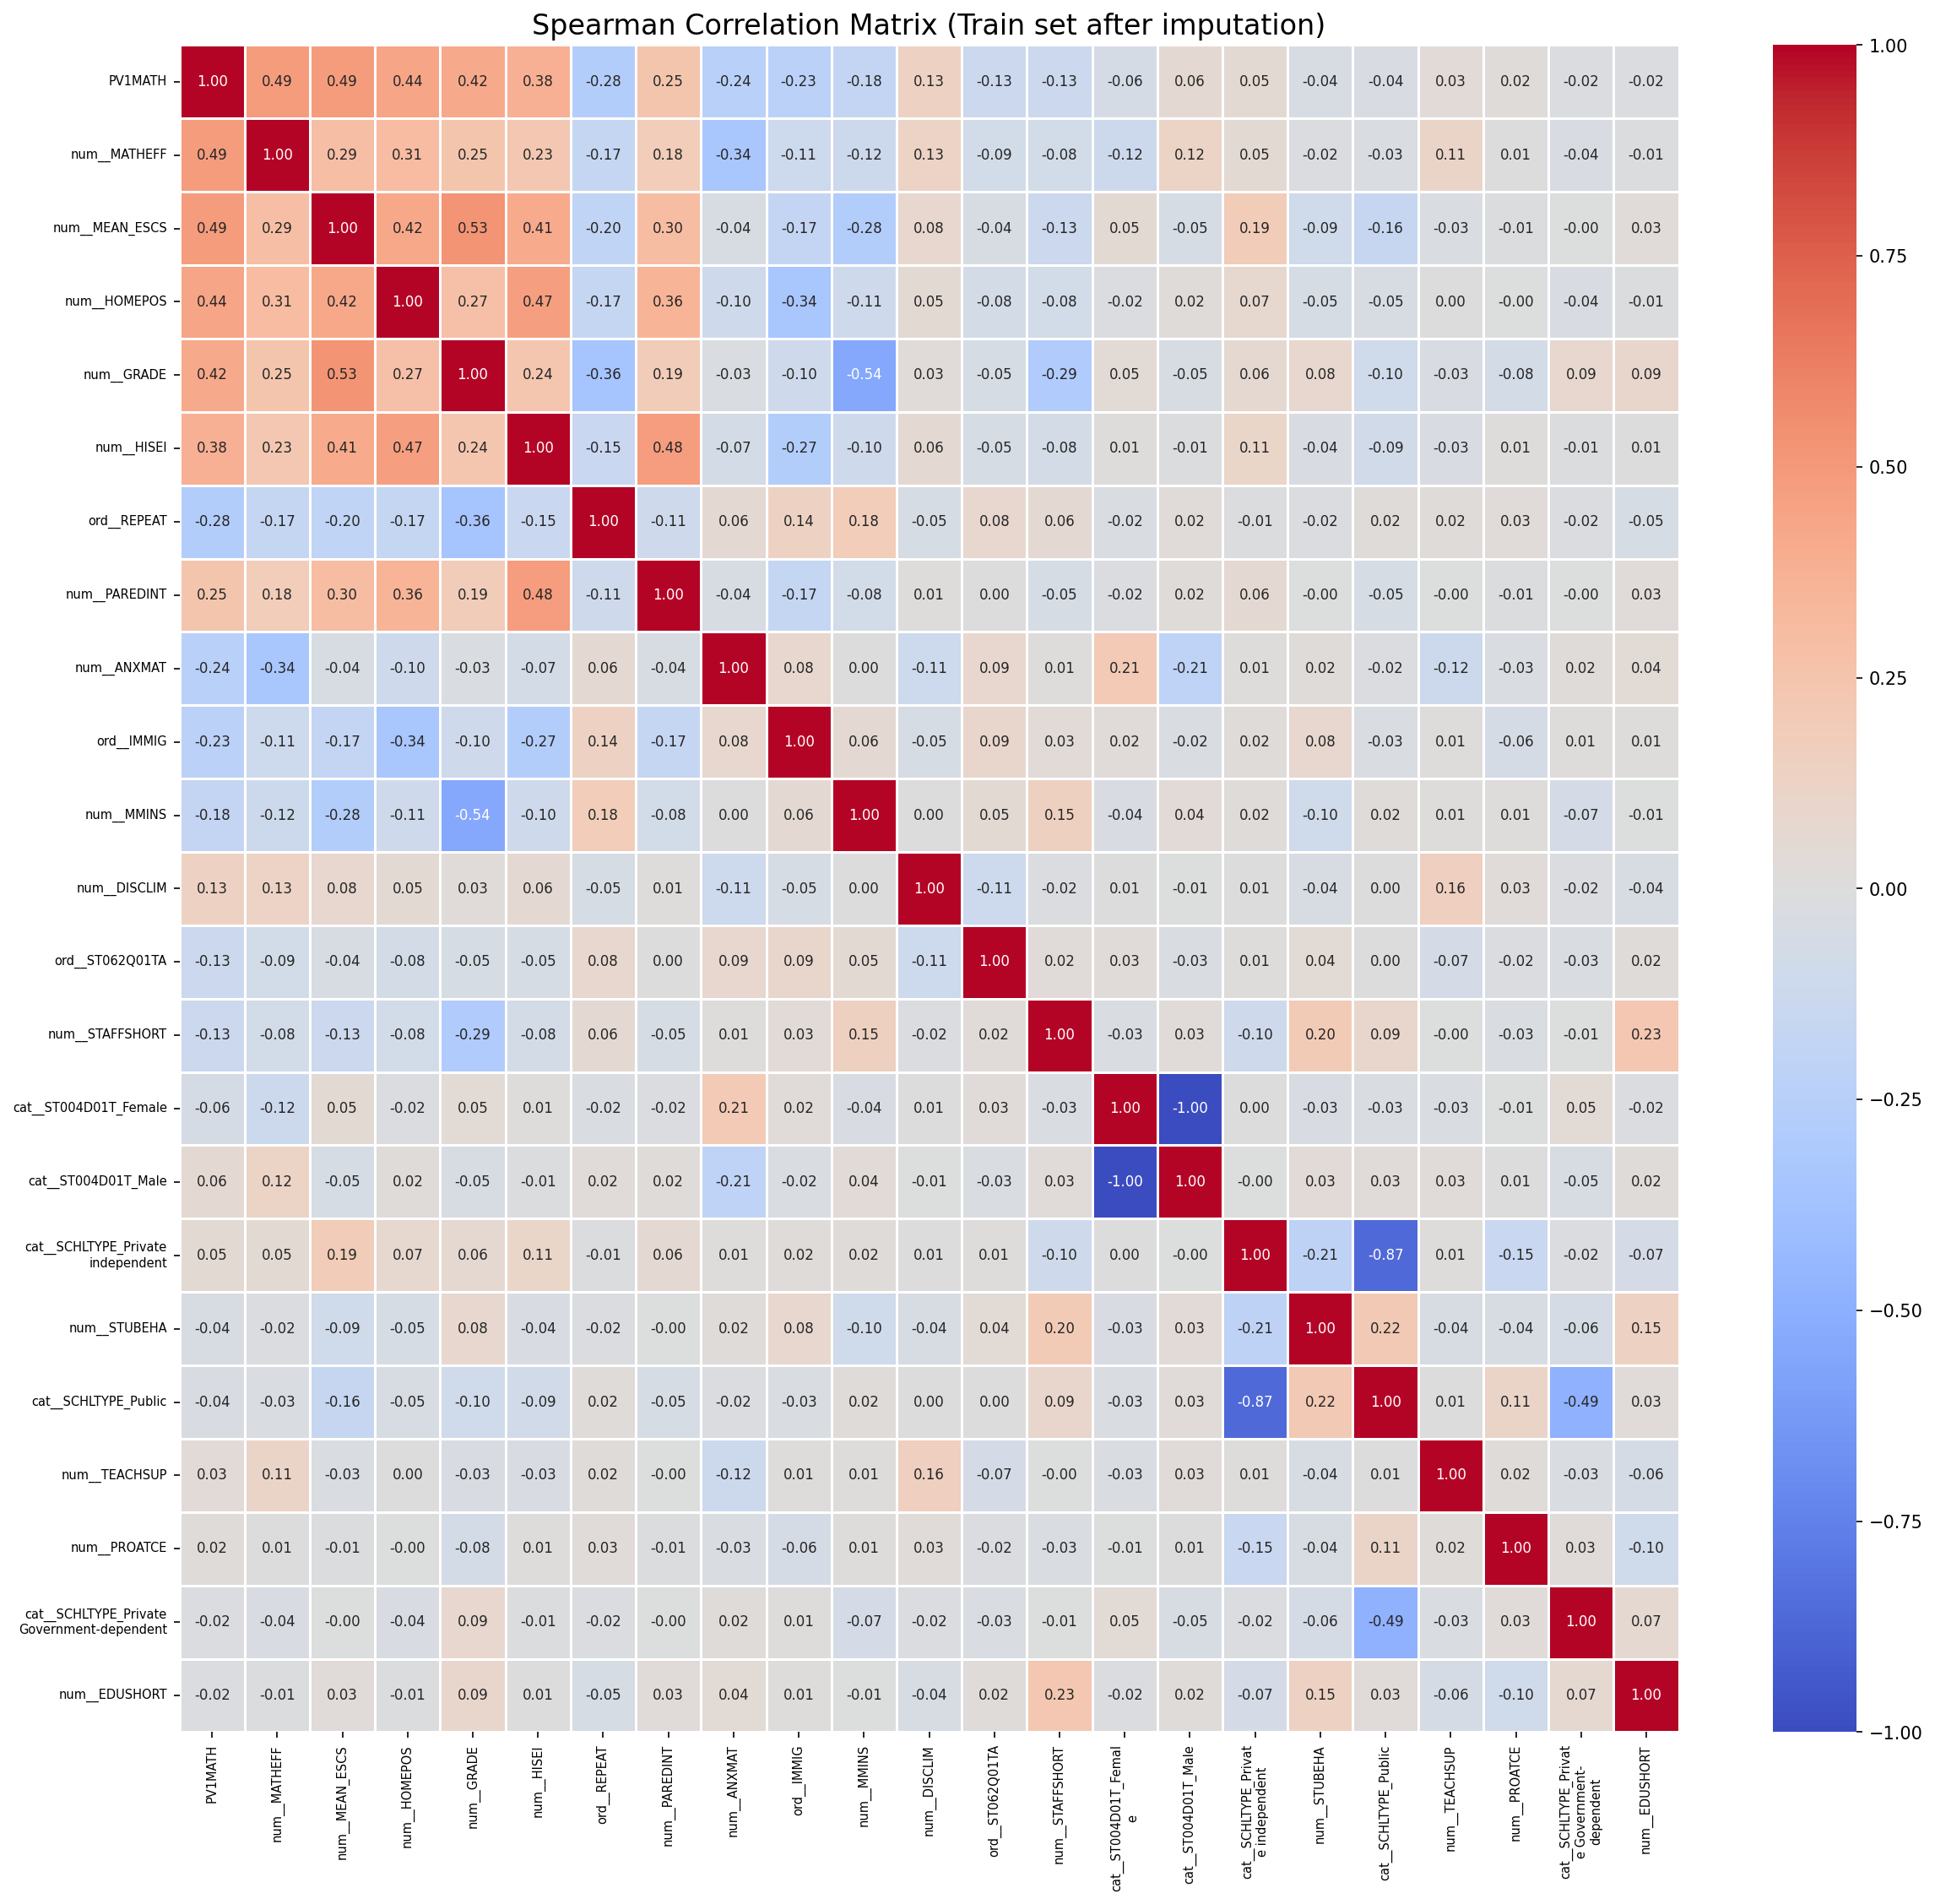


CORRELATIONS WITH TARGET

POSITIVE CORRELATIONS WITH PV1MATH
                                   Correlation
Feature                                       
num__MATHEFF                          0.490289
num__MEAN_ESCS                        0.487596
num__HOMEPOS                          0.438485
num__GRADE                            0.418406
num__HISEI                            0.377014
num__PAREDINT                         0.248540
num__DISCLIM                          0.132944
cat__ST004D01T_Male                   0.060256
cat__SCHLTYPE_Private independent     0.051404
num__TEACHSUP                         0.034768
num__PROATCE                          0.022095

NEGATIVE CORRELATIONS WITH PV1MATH
                                            Correlation
Feature                                                
ord__REPEAT                                   -0.277054
num__ANXMAT                                   -0.244150
ord__IMMIG                                    -0.230720
num__MMINS 

In [5]:
from src.dataset_cleaning_and_preprocessing import create_eda_preprocessor, create_imputed_dataframe
from src.tables import save_correlations_among_features, save_correlations_with_target
from src.visualisations import save_spearman_correlation_matrix

eda_preprocessor = create_eda_preprocessor(X_train)
X_train_imputed_for_eda = eda_preprocessor.fit_transform(X_train)

df_train_set_for_eda = create_imputed_dataframe(
    X_train_imputed_for_eda,
    eda_preprocessor,
    y_train,
    )

# Data analysis: generate and save correlation computations
save_spearman_correlation_matrix(df_train_set_for_eda, "Spearman Correlation Matrix (Train set after imputation)")
save_correlations_with_target(df_train_set_for_eda, "PV1MATH")
save_correlations_among_features(df_train_set_for_eda, "PV1MATH")

# Data analysis: display correlation tables and correlation matrix
display_visualisation("outputs/plots/EDA/train_set/multivariate_plots/Spearman Correlation Matrix (Train set after imputation).png")
print_files("outputs/tables/EDA/train_set/correlations_with_PV1MATH.txt")
print_files("outputs/tables/EDA/train_set/correlations_among_features.txt")


##### **V. FEATURE SELECTION (FOR CLASSIFICATION AND REGRESSION TASKS)**

This step handles the feature selection process separately for both the classification and regression tasks.

For the classification task, PV1MATH is converted into categorical classes according to the thresholds defined in config.py. Those thresholds are based on the literature. For both tasks, the feature selection pipeline is then applied in the following order:

1. Variance Threshold (currently set to 0 to compute feature variances and remove constant features, if any)
2. Mutual Information
3. ANOVA
4. Recursive Feature Elimination (RFE)

For Mutual Information, ANOVA, and RFE, a ranking of all features is established. Moreover, a global ranking is derived by combining these three rankings. The final feature selection decision is then made based on this global ranking.

Finally, feature selection decisions are based only on the training set (to avoid data leakage) but are applied to both the training and test sets.



In [7]:
#y_train/test for classification task
from src.config import CLASS_BOUNDARIES, CLASS_LABELS
from src.feature_selection import run_feature_selection_pipeline

y_train_class = pd.cut(y_train, bins = CLASS_BOUNDARIES, labels = CLASS_LABELS, right = False, include_lowest = True)
y_test_class = pd.cut(y_test,bins = CLASS_BOUNDARIES, labels = CLASS_LABELS, right = False, include_lowest = True)

# regression
(final_features_ranking_reg, 
 variance_threshold_df_reg, 
 ranking_MI_df_reg, 
 ranking_anova_df_reg, 
 ranking_rfe_df_reg, 
 X_train_after_var_thresh_reg, 
 X_test_after_var_thresh_reg, 
 selected_columns_var_thresh_reg) = run_feature_selection_pipeline(X_train_imputed, 
                                                                   X_test_imputed, 
                                                                   y_train, 
                                                                   all_imputed_feature_names, 
                                                                   task = "regression")

#classification
(final_features_ranking_class, 
 variance_threshold_df_class, 
 ranking_MI_df_class, 
 ranking_anova_df_class, 
 ranking_rfe_df_class, 
 X_train_after_var_thresh_class, 
 X_test_after_var_thresh_class, 
 selected_columns_var_thresh_class) = run_feature_selection_pipeline(X_train_imputed, 
                                                                     X_test_imputed, 
                                                                     y_train_class, 
                                                                     all_imputed_feature_names, 
                                                                     task = "classification")

print_files("outputs/tables/feature_selection/variance_threshold_ranking.txt")

print(f"***** REGRESSION TASK *****")
print_files("outputs/tables/feature_selection/regression_mutual_info_ranking.txt")
print_files("outputs/tables/feature_selection/regression_anova_ranking.txt")
print_files("outputs/tables/feature_selection/regression_rfe_ranking.txt")
print_files("outputs/tables/feature_selection/regression_combined_feature_selection_rankings.txt")

print(f"***** CLASSIFICATION TASK *****")
print_files("outputs/tables/feature_selection/classification_mutual_info_ranking.txt")
print_files("outputs/tables/feature_selection/classification_anova_ranking.txt")
print_files("outputs/tables/feature_selection/classification_rfe_ranking.txt")
print_files("outputs/tables/feature_selection/classification_combined_feature_selection_rankings.txt")



 • variance_threshold_ranking.txt saved to outputs/tables/feature_selection

 • regression_mutual_info_ranking.txt saved to outputs/tables/feature_selection

 • regression_anova_ranking.txt saved to outputs/tables/feature_selection

 • regression_rfe_ranking.txt saved to outputs/tables/feature_selection

 • regression_combined_feature_selection_rankings.txt saved to outputs/tables/feature_selection

 • variance_threshold_ranking.txt saved to outputs/tables/feature_selection

 • classification_mutual_info_ranking.txt saved to outputs/tables/feature_selection

 • classification_anova_ranking.txt saved to outputs/tables/feature_selection

 • classification_rfe_ranking.txt saved to outputs/tables/feature_selection

 • classification_combined_feature_selection_rankings.txt saved to outputs/tables/feature_selection

Variance Threshold (threshold = 0) : 20/20 kept

                          Feature    Variance Status
                       num__MMINS 4770.041073   KEPT
                      

##### **VI.I MODEL TRAINING FOR REGRESSION TASK**

This stage trains and evaluates four regression models:
1. Linear Regression (Lasso)
2. Random Forest
3. XGBoost 
4. Support Vector Regression 

It uses different numbers of selected variables (the top 5, 10, 15 and 20 variables). Model selection is based primarily on the best score obtained via 5-fold cross-validation on the training dataset, following hyperparameter optimisation. 

The final models are then evaluated on an independent test set to assess their generalisation ability. Finally, detailed results, summary tables and diagnostic plots are generated to compare the models and identify the optimal number of variables.


In [6]:

from src.model_training import evaluate_k_values
from src.tables import save_detailed_results_by_k, save_summary_of_metrics
from src.visualisations import (
    save_learning_curves_plot_all_models,
    save_multiple_metrics_vs_features_plot,
    save_residuals_plot_from_all_results
)

regression_results_df, regression_all_results_dic = evaluate_k_values(
    X_train_after_var_thresh_reg,
    y_train,
    X_test_after_var_thresh_reg,
    y_test,
    final_features_ranking=final_features_ranking_reg,
    feature_names=selected_columns_var_thresh_reg,
    model_names=['LR', 'RF', 'XGBoost', 'SVR'],
    task='regression',
    k_values=[5, 10, 15, 20]
)

save_detailed_results_by_k(regression_all_results_dic, task='regression')
save_summary_of_metrics(regression_results_df, task='regression')
save_multiple_metrics_vs_features_plot(regression_results_df, task='regression')

k_chosen = 10
save_residuals_plot_from_all_results(regression_all_results_dic, k_chosen=k_chosen)
save_learning_curves_plot_all_models(regression_all_results_dic, k_chosen=k_chosen, X_train_after_var_thresh=X_train_after_var_thresh_reg, y_train=y_train, task='regression')

# Display model training results, tables and plots
print_files(f"{TABLES_DIR}/model_training/regression_detailed_results_by_k.txt")
print_files(f"{TABLES_DIR}/model_training/regression_summary_of_metrics.txt")

display_visualisation(f"{PLOTS_DIR}/model_training/regression_metrics_vs_features_plot.png")
display_visualisation(f"{PLOTS_DIR}/model_training/regression_residual_plots_for_{k_chosen}_features.png")
display_visualisation(f"{PLOTS_DIR}/model_training/regression_learning_curves_top_{k_chosen}_features.png")


NameError: name 'X_train_after_var_thresh_reg' is not defined

##### **VI.II MODEL TRAINING FOR CLASSIFICATION TASK**

This stage trains and evaluates four regression models:
1. Logistic Regression
2. Random Forest
3. XGBoost 
4. Support Vector Classification 

It uses different numbers of selected variables (the top 5, 10, 15 and 20 variables). Model selection is based primarily on the best score obtained via 5-fold cross-validation on the training dataset, following hyperparameter optimisation. 

The final models are then evaluated on an independent test set to assess their generalisation ability. Finally, detailed results, summary tables and diagnostic plots are generated to compare the models and identify the optimal number of variables.


In [ ]:
# Evaluate classification models for different top-k features
from src.visualisations import save_confusion_matrices_plot_all_models

classification_results_df, classification_all_results_dic = evaluate_k_values(
    X_train_after_var_thresh_class, y_train_class, X_test_after_var_thresh_class, y_test_class,
    final_features_ranking = final_features_ranking_class,
    feature_names = selected_columns_var_thresh_class,
    model_names=['LR', 'RF', 'XGBoost', 'SVC'],
    task='classification',
    k_values=[5, 10, 15, 20]
    )

save_detailed_results_by_k(classification_all_results_dic, task='classification')
save_summary_of_metrics(classification_results_df, task='classification')

save_multiple_metrics_vs_features_plot(classification_results_df, task='classification')
save_confusion_matrices_plot_all_models(classification_all_results_dic, k_chosen=10, class_labels=CLASS_LABELS)

save_learning_curves_plot_all_models(
    classification_all_results_dic, 
    k_chosen=10, 
    X_train_after_var_thresh=X_train_after_var_thresh_class, 
    y_train=y_train_class, 
    task='classification'
    )

k_chosen = 10
# Display model training results, tables and plots
print_files(f"{TABLES_DIR}/model_training/classification_detailed_results_by_k.txt")
print_files(f"{TABLES_DIR}/model_training/classification_summary_of_metrics.txt")

display_visualisation(f"{PLOTS_DIR}/model_training/classification_metrics_vs_features_plot.png")
display_visualisation(f"{PLOTS_DIR}/model_training/classification_learning_curves_top_{k_chosen}_features.png")
display_visualisation(f"{PLOTS_DIR}/model_training/confusion_matrices_top_{k_chosen}_features.png")


##### **VII. SHAP ANALYSIS**

This section presents the analysis of model explainability using SHAP (SHapley Additive exPlanations). The aim is to identify the most influential features in prediction, assess the consistency of explanations across different models in the Rashomon set, and measure their stability with respect to data variations.

The main steps of this analysis are as follows:

1. To build the Rashomon set: the set of models whose cross validation performance lies within 0.05 of the best performing model.

2. To compute local SHAP values for each model retained.

3. Compute global SHAP feature importances by averaging the absolute SHAP values across all observations. From this computation, a global feature importance ranking is established.

4. Visualise these importances using a global bar plot and a SHAP summary plot.

5. Evaluate inter-model agreement to determine to which extent different models identify the same important variables.

6. Evaluate intra-model stability using bootstrapping to measure the robustness of the SHAP importances with the help of the coeficient of variation. A seed is fixed for reproductibility purpose. 

7. Identify the most robust features, which are those both highly important and stable across models and bootstrap resamples. The number of retained features is specified by the user and must not exceed the number of features used for model training.

In [ ]:
from src.SHAP_analysis import run_complete_shap_analysis_and_classification
from src.visualisations import barplot_global_shap_rankings, shap_summary_plot

(global_shap_rankings, 
shap_values_for_all_models, 
X_test_k, 
feature_names_k, 
number_of_features_chosen_for_model_training) = run_complete_shap_analysis_and_classification(
    X_train = X_train_after_var_thresh_reg,
    X_test = X_test_after_var_thresh_reg,
    number_of_features_chosen_for_model_training = 10,
    task ='regression',
    all_training_model_results_dic = regression_all_results_dic,
    rashomon_set_threshold = 0.05,
    number_of_features_retained_for_final_classification = 5,
    )

print_files("outputs/tables/SHAP_analysis/rashomon_set.txt")
print_files("outputs/tables/SHAP_analysis/global_shap_rankings.txt")

barplot_global_shap_rankings(global_shap_rankings, number_of_features_chosen_for_model_training)
shap_summary_plot(shap_values_for_all_models, feature_names_k)

display_visualisation(f"{PLOTS_DIR}/SHAP_analysis/Global_SHAP_feature_importances_barplot.png")
display_visualisation(f"{PLOTS_DIR}/SHAP_analysis/SHAP_summary_plot.png")

print_files("outputs/tables/SHAP_analysis/feature_agreement_stats.txt")
print_files("outputs/tables/SHAP_analysis/inter_model_concordance_agreement.txt")
print_files("outputs/tables/SHAP_analysis/intra_model_stability_assessment.txt")
print_files("outputs/tables/SHAP_analysis/feature_robustness_assessment.txt")
    